In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("tmdb_5000_cleaned neu.csv", sep=";")

In [6]:
df.head()

,title,budget,runtime,release_year,is_us_production,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,popularity
0,Avatar,237000000,162.0,2009.0,1,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,150.437577
1,Pirates of the Caribbean: At World's End,300000000,169.0,2007.0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,139.082615
2,Spectre,245000000,148.0,2015.0,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,107.376788
3,The Dark Knight Rises,250000000,165.0,2012.0,1,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,112.312950
4,John Carter,260000000,132.0,2012.0,1,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,43.926995


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3764 entries, 0 to 3763
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  3764 non-null   object 
 1   budget                 3764 non-null   int64  
 2   runtime                3764 non-null   float64
 3   release_year           3764 non-null   float64
 4   is_us_production       3764 non-null   int64  
 5   genre_Action           3764 non-null   int64  
 6   genre_Adventure        3764 non-null   int64  
 7   genre_Animation        3764 non-null   int64  
 8   genre_Comedy           3764 non-null   int64  
 9   genre_Crime            3764 non-null   int64  
 10  genre_Documentary      3764 non-null   int64  
 11  genre_Drama            3764 non-null   int64  
 12  genre_Family           3764 non-null   int64  
 13  genre_Fantasy          3764 non-null   int64  
 14  genre_Foreign          3764 non-null   int64  
 15  genr

In [18]:

pd.options.display.float_format = '{:,.2f}'.format

In [19]:
df.describe()

,budget,runtime,release_year,is_us_production,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,popularity
count,"3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00",...,"3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00"
mean,"37,058,535.21",109.32,"2,002.08",0.88,0.27,0.19,0.06,0.35,0.16,0.01,...,0.11,0.04,0.08,0.18,0.13,0.00,0.29,0.04,0.02,26.00
std,"42,652,055.19",20.75,12.88,0.33,0.44,0.39,0.23,0.48,0.36,0.12,...,0.31,0.19,0.27,0.38,0.33,0.03,0.45,0.18,0.13,34.44
min,1.00,0.00,"1,916.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"8,000,000.00",95.00,"1,998.75",1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.98
50%,"23,000,000.00",105.50,"2,005.00",1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.61
75%,"50,000,000.00",120.00,"2,011.00",1.00,1.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,33.93
max,"380,000,000.00",338.00,"2,016.00",1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,875.58


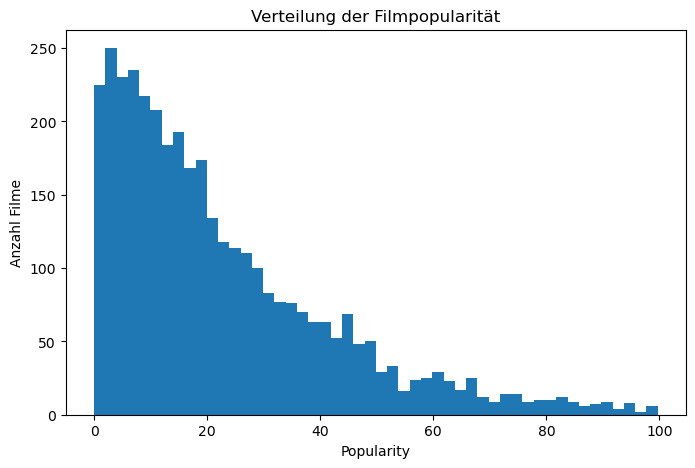

In [17]:
filtered_popularity = df[df['popularity'] <= 100]

plt.figure(figsize=(8,5))

plt.hist(filtered_popularity['popularity'], bins=50)

plt.xlabel("Popularity")
plt.ylabel("Anzahl Filme")
plt.title("Verteilung der Filmpopularität")

plt.show()

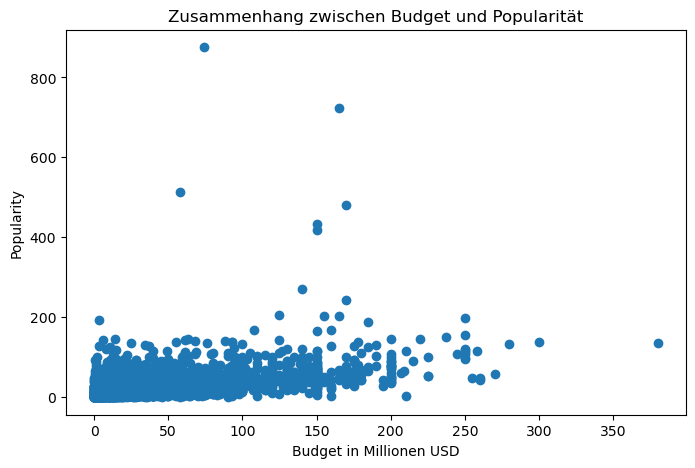

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df['budget'] / 1000000, df['popularity'])

plt.xlabel("Budget in Millionen USD")
plt.ylabel("Popularity")
plt.title("Zusammenhang zwischen Budget und Popularität")

plt.show()

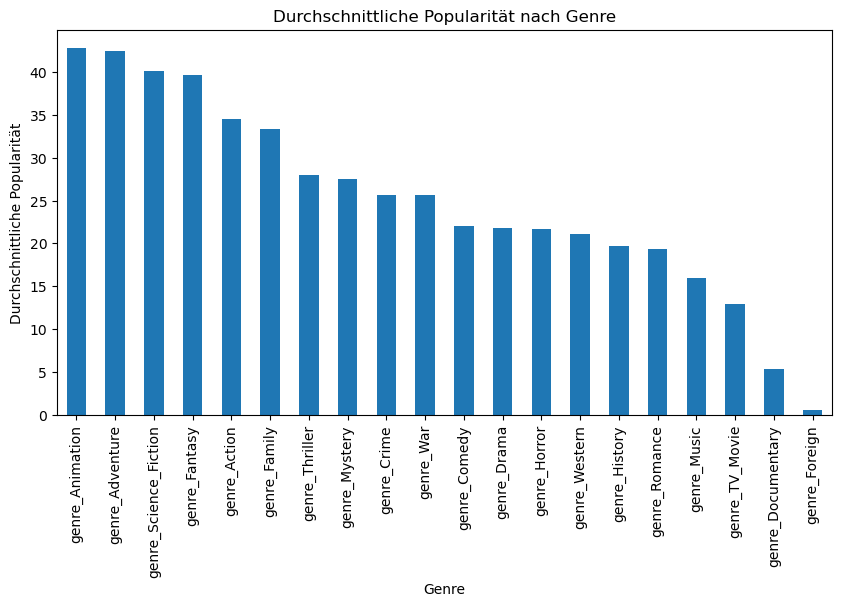

In [15]:
genre_columns = [col for col in df.columns if "genre_" in col]

genre_popularity = {}

for genre in genre_columns:
    genre_popularity[genre] = df[df[genre] == 1]['popularity'].mean()

genre_popularity = pd.Series(genre_popularity).sort_values(ascending=False)

plt.figure(figsize=(10,5))

genre_popularity.plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Durchschnittliche Popularität")
plt.title("Durchschnittliche Popularität nach Genre")

plt.show()